In [1]:
import time
import tracemalloc
import random
import matplotlib.pyplot as plt

In [5]:
# ============================================================
# SORTING ALGORITHMS
# ============================================================

def bubble_sort(arr):
    arr = arr.copy()
    n = len(arr)

    for i in range(n):
        swapped = False

        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True

        if not swapped:
            break

    return arr


In [6]:
def insertion_sort(arr):
    arr = arr.copy()

    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1

        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1

        arr[j + 1] = key

    return arr

In [7]:
def merge_sort(arr):
    if len(arr) <= 1:
        return arr.copy()

    mid = len(arr) // 2

    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result



In [8]:
def quick_sort(arr):
    if len(arr) <= 1:
        return arr.copy()

    pivot = arr[len(arr) // 2]

    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]

    return quick_sort(left) + middle + quick_sort(right)

In [9]:
# ============================================================
# FIBONACCI ALGORITHMS
# ============================================================

def fibonacci_recursive(n):
    if n <= 1:
        return n

    return fibonacci_recursive(n - 1) + fibonacci_recursive(n - 2)



In [10]:

def fibonacci_iterative(n):
    a, b = 0, 1

    for _ in range(n):
        a, b = b, a + b

    return a


In [11]:
def fibonacci_dynamic(n):
    if n <= 1:
        return n

    dp = [0] * (n + 1)
    dp[1] = 1

    for i in range(2, n + 1):
        dp[i] = dp[i - 1] + dp[i - 2]

    return dp[n]

In [12]:
# ============================================================
# PERFORMANCE MEASUREMENT FUNCTION
# ============================================================

def measure_performance(function, *args):
    """
    Measures:
    1. Execution time in milliseconds
    2. Peak memory consumption in KB
    """

    tracemalloc.start()

    start_time = time.perf_counter()

    result = function(*args)

    end_time = time.perf_counter()

    current, peak = tracemalloc.get_traced_memory()

    tracemalloc.stop()

    execution_time = (end_time - start_time) * 1000
    memory_usage = peak / 1024

    return execution_time, memory_usage, result


In [14]:
# ============================================================
# SORTING PERFORMANCE TEST
# ============================================================

sorting_algorithms = {
    "Bubble Sort": bubble_sort,
    "Insertion Sort": insertion_sort,
    "Merge Sort": merge_sort,
    "Quick Sort": quick_sort
}

sorting_sizes = [100, 500, 1000, 2000, 5000]

sorting_time = {name: [] for name in sorting_algorithms}
sorting_memory = {name: [] for name in sorting_algorithms}

print("=" * 70)
print("SORTING ALGORITHMS PERFORMANCE")
print("=" * 70)
for size in sorting_sizes:

    # Same input data for fair comparison
    data = [random.randint(1, 100000) for _ in range(size)]

    print(f"\nInput Size: {size}")

    for name, algorithm in sorting_algorithms.items():

        # Avoid very large input for slow O(n²) algorithms
        if name in ["Bubble Sort", "Insertion Sort"] and size > 2000:
            sorting_time[name].append(None)
            sorting_memory[name].append(None)
            print(f"{name:<20}: Skipped for large input")
            continue

        execution_time, memory_usage, result = measure_performance(
            algorithm, data
        )

        sorting_time[name].append(execution_time)
        sorting_memory[name].append(memory_usage)

        print(
            f"{name:<20}: "
            f"Time = {execution_time:.4f} ms, "
            f"Memory = {memory_usage:.2f} KB"
        )


SORTING ALGORITHMS PERFORMANCE

Input Size: 100
Bubble Sort         : Time = 1.8552 ms, Memory = 0.96 KB
Insertion Sort      : Time = 0.2455 ms, Memory = 0.93 KB
Merge Sort          : Time = 0.7775 ms, Memory = 2.27 KB
Quick Sort          : Time = 0.7288 ms, Memory = 5.84 KB

Input Size: 500
Bubble Sort         : Time = 106.2886 ms, Memory = 153.72 KB
Insertion Sort      : Time = 41.0507 ms, Memory = 4.04 KB
Merge Sort          : Time = 2.1647 ms, Memory = 8.26 KB
Quick Sort          : Time = 1.9272 ms, Memory = 18.20 KB

Input Size: 1000
Bubble Sort         : Time = 485.6502 ms, Memory = 157.63 KB
Insertion Sort      : Time = 215.3766 ms, Memory = 157.29 KB
Merge Sort          : Time = 5.5641 ms, Memory = 16.84 KB
Quick Sort          : Time = 3.8459 ms, Memory = 33.16 KB

Input Size: 2000
Bubble Sort         : Time = 4262.7371 ms, Memory = 166.08 KB
Insertion Sort      : Time = 1613.7695 ms, Memory = 167.20 KB
Merge Sort          : Time = 29.8992 ms, Memory = 33.45 KB
Quick Sort      

In [15]:
# ============================================================
# FIBONACCI PERFORMANCE TEST
# ============================================================

fibonacci_algorithms = {
    "Recursive Fibonacci": fibonacci_recursive,
    "Iterative Fibonacci": fibonacci_iterative,
    "Dynamic Fibonacci": fibonacci_dynamic
}

# Recursive Fibonacci becomes extremely slow for large n
fib_sizes = [5, 10, 15, 20, 25, 30, 35]

fib_time = {name: [] for name in fibonacci_algorithms}
fib_memory = {name: [] for name in fibonacci_algorithms}

print("\n")
print("=" * 70)
print("FIBONACCI ALGORITHMS PERFORMANCE")
print("=" * 70)

for n in fib_sizes:

    print(f"\nFibonacci n = {n}")

    for name, algorithm in fibonacci_algorithms.items():

        execution_time, memory_usage, result = measure_performance(
            algorithm, n
        )

        fib_time[name].append(execution_time)
        fib_memory[name].append(memory_usage)

        print(
            f"{name:<25}: "
            f"Time = {execution_time:.4f} ms, "
            f"Memory = {memory_usage:.2f} KB"
        )





FIBONACCI ALGORITHMS PERFORMANCE

Fibonacci n = 5
Recursive Fibonacci      : Time = 0.0294 ms, Memory = 0.07 KB
Iterative Fibonacci      : Time = 0.0320 ms, Memory = 0.15 KB
Dynamic Fibonacci        : Time = 0.0334 ms, Memory = 0.20 KB

Fibonacci n = 10
Recursive Fibonacci      : Time = 0.0448 ms, Memory = 0.00 KB
Iterative Fibonacci      : Time = 0.0143 ms, Memory = 0.08 KB
Dynamic Fibonacci        : Time = 0.0248 ms, Memory = 0.16 KB

Fibonacci n = 15
Recursive Fibonacci      : Time = 0.3585 ms, Memory = 0.06 KB
Iterative Fibonacci      : Time = 0.0116 ms, Memory = 0.12 KB
Dynamic Fibonacci        : Time = 0.0157 ms, Memory = 0.22 KB

Fibonacci n = 20
Recursive Fibonacci      : Time = 3.7575 ms, Memory = 0.16 KB
Iterative Fibonacci      : Time = 0.0174 ms, Memory = 0.12 KB
Dynamic Fibonacci        : Time = 0.0251 ms, Memory = 0.41 KB

Fibonacci n = 25
Recursive Fibonacci      : Time = 23.8814 ms, Memory = 0.39 KB
Iterative Fibonacci      : Time = 0.0226 ms, Memory = 0.12 KB
Dynamic

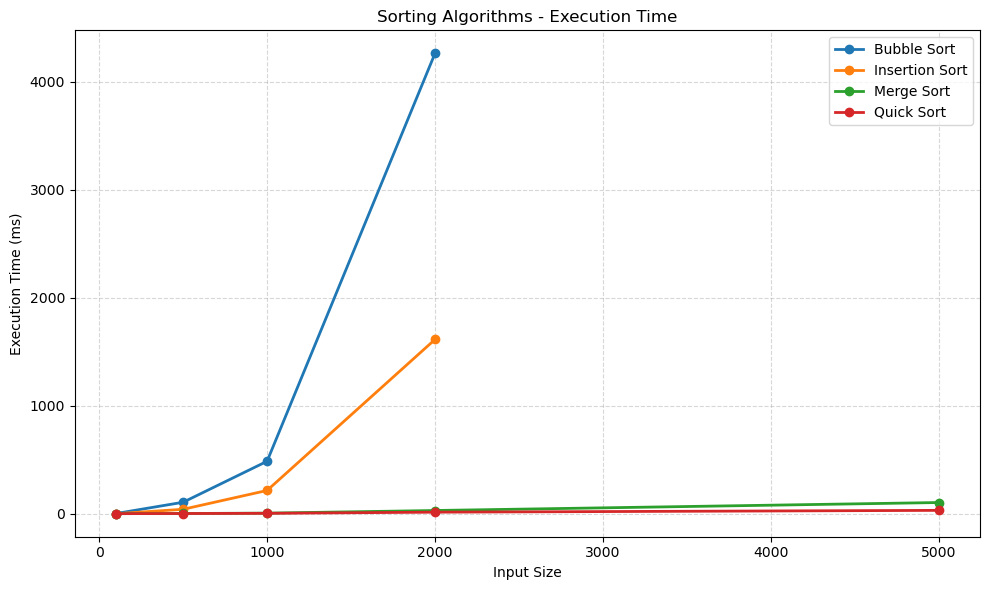

In [16]:
# ============================================================
# GRAPH 1: SORTING EXECUTION TIME
# ============================================================

plt.figure(figsize=(10, 6))

for name in sorting_algorithms:

    plt.plot(
        sorting_sizes,
        sorting_time[name],
        marker="o",
        linewidth=2,
        label=name
    )

plt.title("Sorting Algorithms - Execution Time")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("sorting_execution_time.png", dpi=300)
plt.show()

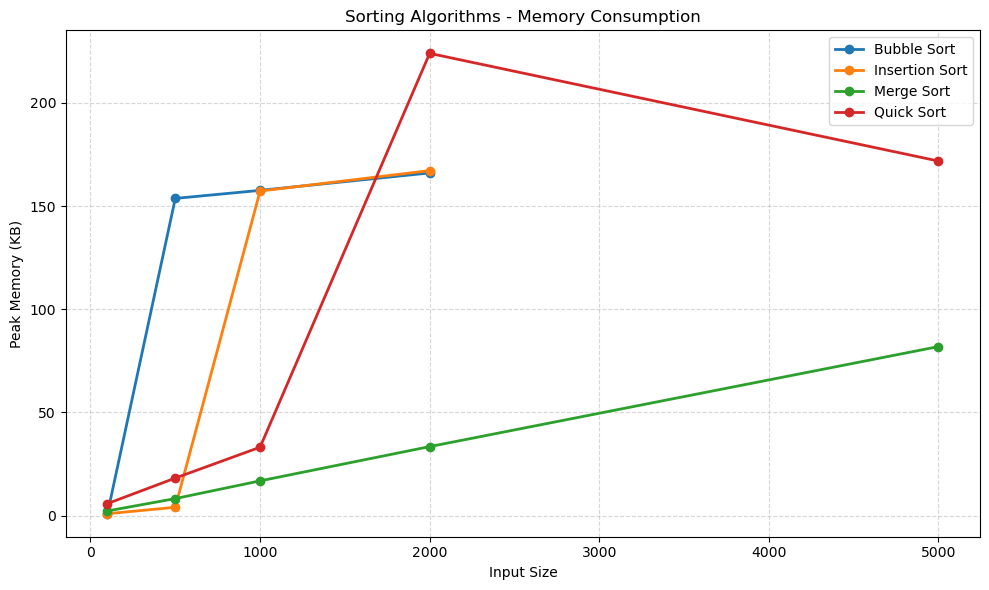

In [17]:
# ============================================================
# GRAPH 2: SORTING MEMORY CONSUMPTION
# ============================================================

plt.figure(figsize=(10, 6))

for name in sorting_algorithms:

    plt.plot(
        sorting_sizes,
        sorting_memory[name],
        marker="o",
        linewidth=2,
        label=name
    )

plt.title("Sorting Algorithms - Memory Consumption")
plt.xlabel("Input Size")
plt.ylabel("Peak Memory (KB)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("sorting_memory_consumption.png", dpi=300)
plt.show()


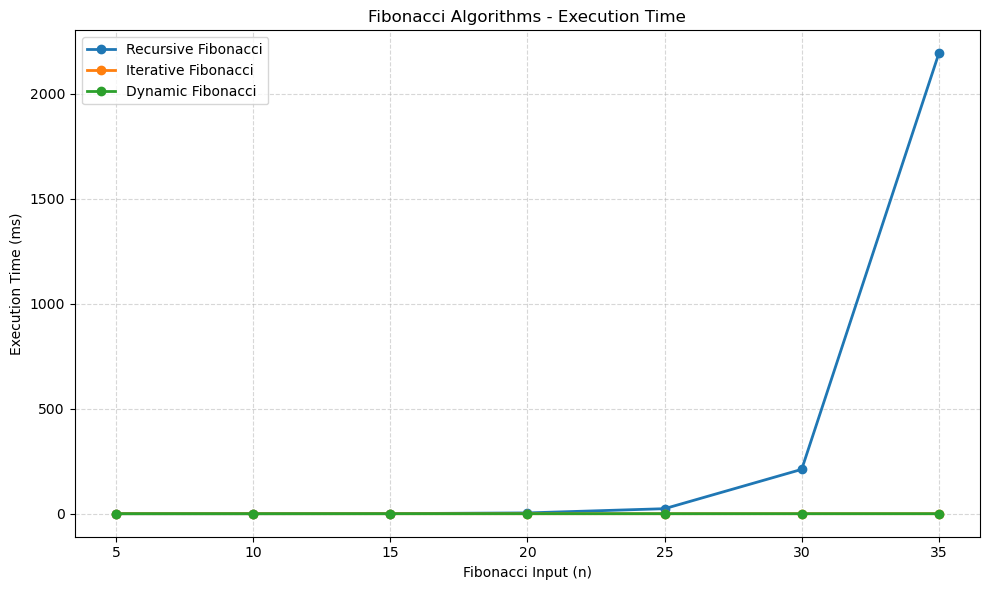

In [18]:
# ============================================================
# GRAPH 3: FIBONACCI EXECUTION TIME
# ============================================================

plt.figure(figsize=(10, 6))

for name in fibonacci_algorithms:

    plt.plot(
        fib_sizes,
        fib_time[name],
        marker="o",
        linewidth=2,
        label=name
    )

plt.title("Fibonacci Algorithms - Execution Time")
plt.xlabel("Fibonacci Input (n)")
plt.ylabel("Execution Time (ms)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("fibonacci_execution_time.png", dpi=300)
plt.show()



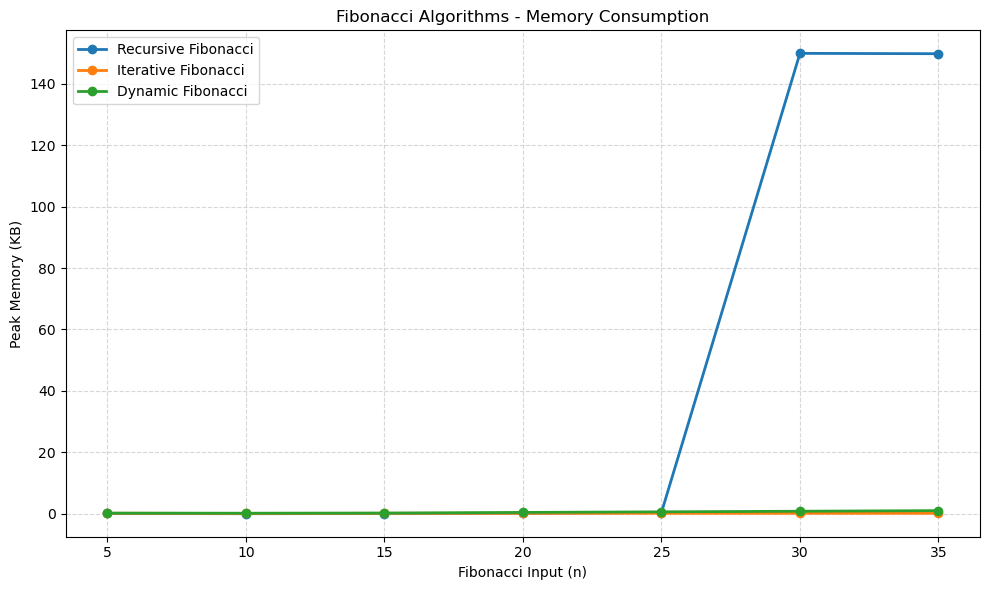

In [19]:
# ============================================================
# GRAPH 4: FIBONACCI MEMORY CONSUMPTION
# ============================================================

plt.figure(figsize=(10, 6))

for name in fibonacci_algorithms:

    plt.plot(
        fib_sizes,
        fib_memory[name],
        marker="o",
        linewidth=2,
        label=name
    )

plt.title("Fibonacci Algorithms - Memory Consumption")
plt.xlabel("Fibonacci Input (n)")
plt.ylabel("Peak Memory (KB)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("fibonacci_memory_consumption.png", dpi=300)
plt.show()



In [20]:
# ============================================================
# OBSERVATIONS
# ============================================================

print("\n")
print("=" * 70)
print("OBSERVATIONS")
print("=" * 70)

print("""
1. Sorting Algorithms
---------------------
• Bubble Sort and Insertion Sort generally require O(n²) time
  in the average/worst case.

• Merge Sort has O(n log n) time complexity and performs well
  as the input size increases.

• Quick Sort generally performs faster than the simple O(n²)
  sorting algorithms for large random inputs.

• Bubble Sort and Insertion Sort become considerably slower
  as the input size increases.

• Merge Sort uses additional memory because temporary lists
  are created during the merging process.

• Quick Sort in this implementation also creates additional
  lists, so its memory consumption can increase with input size.


2. Fibonacci Algorithms
-----------------------
• Recursive Fibonacci has exponential time complexity,
  approximately O(2^n), making it extremely slow for large n.

• Iterative Fibonacci has O(n) time complexity and is much
  faster than the recursive approach.

• Dynamic Programming Fibonacci also has O(n) time complexity.

• The recursive approach uses additional call-stack memory
  because many recursive function calls are created.

• Dynamic Programming stores intermediate Fibonacci values,
  so it uses O(n) additional memory.

• The iterative approach requires only a few variables and
  therefore uses approximately O(1) extra space.


3. Overall Conclusion
---------------------
• Algorithms with better time complexity generally scale
  better as the input size increases.

• Recursive Fibonacci is the least efficient algorithm among
  the Fibonacci implementations tested.

• Iterative Fibonacci provides an excellent balance between
  execution time and memory consumption.

• Merge Sort and Quick Sort are generally more suitable for
  large datasets than Bubble Sort and Insertion Sort.

• Actual execution time and memory values depend on the
  computer, Python version, and system load. Therefore,
  algorithmic complexity is more important than one individual
  measurement.
""")



OBSERVATIONS

1. Sorting Algorithms
---------------------
• Bubble Sort and Insertion Sort generally require O(n²) time
  in the average/worst case.

• Merge Sort has O(n log n) time complexity and performs well
  as the input size increases.

• Quick Sort generally performs faster than the simple O(n²)
  sorting algorithms for large random inputs.

• Bubble Sort and Insertion Sort become considerably slower
  as the input size increases.

• Merge Sort uses additional memory because temporary lists
  are created during the merging process.

• Quick Sort in this implementation also creates additional
  lists, so its memory consumption can increase with input size.


2. Fibonacci Algorithms
-----------------------
• Recursive Fibonacci has exponential time complexity,
  approximately O(2^n), making it extremely slow for large n.

• Iterative Fibonacci has O(n) time complexity and is much
  faster than the recursive approach.

• Dynamic Programming Fibonacci also has O(n) time complexit

In [21]:
# ============================================================
# FINAL SUMMARY TABLE
# ============================================================

print("\n")
print("=" * 70)
print("ALGORITHM COMPLEXITY SUMMARY")
print("=" * 70)

print("""
+----------------------+--------------+---------------+
| Algorithm            | Time         | Extra Space   |
+----------------------+--------------+---------------+
| Bubble Sort          | O(n²)        | O(1)          |
| Insertion Sort       | O(n²)        | O(1)          |
| Merge Sort           | O(n log n)   | O(n)          |
| Quick Sort           | O(n log n)*  | O(n)*         |
| Recursive Fibonacci  | O(2^n)       | O(n)          |
| Iterative Fibonacci  | O(n)         | O(1)          |
| Dynamic Fibonacci    | O(n)        | O(n)          |
+----------------------+--------------+---------------+

* Average-case complexity for Quick Sort.
""")



ALGORITHM COMPLEXITY SUMMARY

+----------------------+--------------+---------------+
| Algorithm            | Time         | Extra Space   |
+----------------------+--------------+---------------+
| Bubble Sort          | O(n²)        | O(1)          |
| Insertion Sort       | O(n²)        | O(1)          |
| Merge Sort           | O(n log n)   | O(n)          |
| Quick Sort           | O(n log n)*  | O(n)*         |
| Recursive Fibonacci  | O(2^n)       | O(n)          |
| Iterative Fibonacci  | O(n)         | O(1)          |
| Dynamic Fibonacci    | O(n)        | O(n)          |
+----------------------+--------------+---------------+

* Average-case complexity for Quick Sort.

